In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import os

# List of the 8 representative benchmark files
file_list = [
    'mmlu_external.csv', 'gsm8k_external.csv', 'hella_swag_external.csv',
    'gpqa_diamond.csv', 'frontiermath.csv', 'arc_agi_external.csv',
    'swe_bench_verified.csv', 'chess_puzzles.csv'
]
folder_path = 'benchmark_data'
all_data = []

for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    try:
        temp_df = pd.read_csv(file_path)
        
        # Standardizing column names across different Epoch AI datasets
        column_mapping = {
            'Model version': 'model_name',
            'Release date': 'release_date',
            'Organization': 'maker',        
            'EM': 'score',
            'mean_score': 'score',
            'Score': 'score',
            'Overall accuracy': 'score'
        }
        temp_df = temp_df.rename(columns=column_mapping)
        
        # Extracting benchmark name from filename
        bench_name = file_name.replace('.csv', '').replace('_external', '').replace('_verified', '').upper()
        temp_df['benchmark_name'] = bench_name
        
        # Handling missing organization info
        if 'maker' not in temp_df.columns:
            temp_df['maker'] = 'Unknown'
            
        if 'model_name' in temp_df.columns and 'score' in temp_df.columns and 'release_date' in temp_df.columns:
            temp_df = temp_df[['model_name', 'release_date', 'score', 'benchmark_name', 'maker']]
            all_data.append(temp_df)
            
    except Exception as e:
        print(f"Error reading {file_name}: {e}")

if all_data:
    df = pd.concat(all_data, ignore_index=True)
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['score'] = pd.to_numeric(df['score'], errors='coerce')
    
    # Normalizing scores to 0-100 range
    if df['score'].max() <= 1.0:
        df['score'] = df['score'] * 100
        
    df = df.dropna(subset=['release_date', 'score'])
    print(f"Successfully loaded and merged {len(all_data)} benchmark datasets.")

Successfully loaded and merged 8 benchmark datasets.


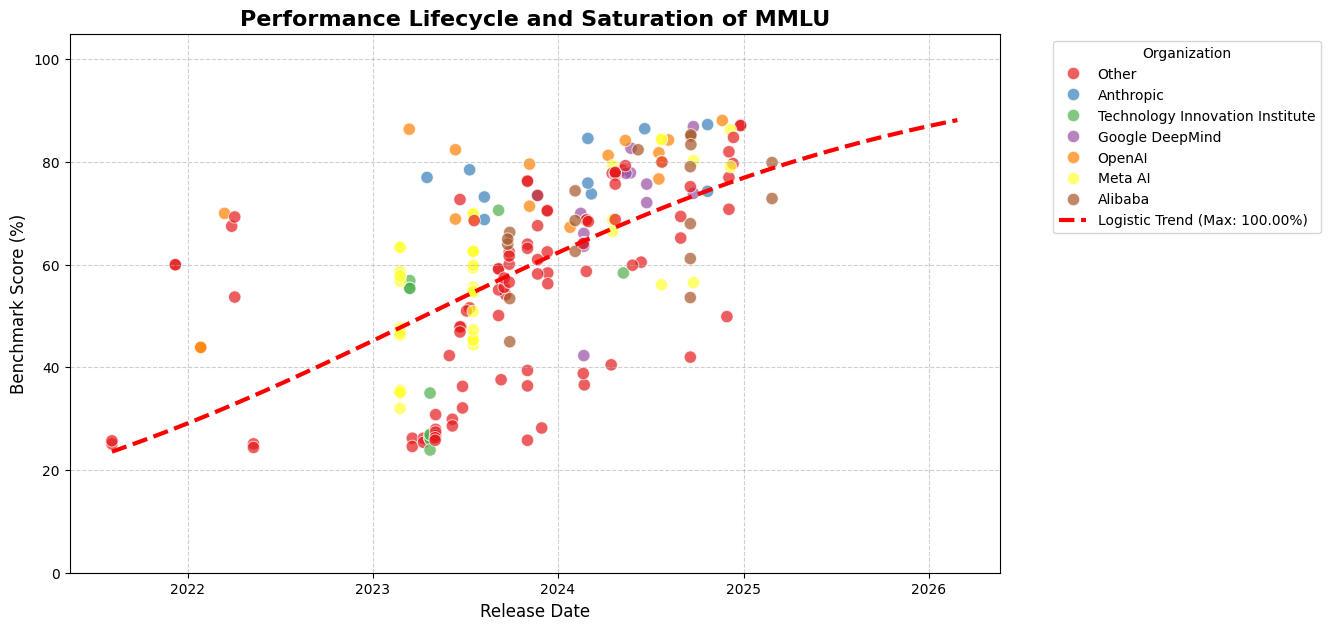

The theoretical ceiling of MMLU is: 100.0000%


In [30]:
def logistic_func(x, L, k, x0):
    """Standard logistic growth function for S-curve fitting."""
    return L / (1 + np.exp(-k * (x - x0)))

def plot_lifecycle_curve(df, target_benchmark):
    """
    Plots the performance lifecycle of a specific benchmark using an S-curve.
    Returns the fitted parameters (popt) for further analysis.
    """
    b_df = df[df['benchmark_name'] == target_benchmark].copy()
    
    if b_df.empty:
        print(f"No data found for {target_benchmark}")
        return None

    # Calculating time delta in months for curve fitting
    # Using 30.44 days as the average month duration
    b_df['months_since_start'] = (b_df['release_date'] - b_df['release_date'].min()).dt.days / 30.44
    x_data = b_df['months_since_start'].values
    y_data = b_df['score'].values

    # Fitting the S-curve
    # Constraint: Max score (L) is capped at 100%
    try:
        popt, _ = curve_fit(
            logistic_func, 
            x_data, 
            y_data, 
            p0=[100, 0.1, np.median(x_data)], 
            bounds=([0, 0, -100], [100, 1, 1000])
        )
    except RuntimeError:
        # Fallback if optimization fails
        popt = [100, 0.1, np.median(x_data)]

    # Grouping organizations to keep the legend clean (Top 6 + Other)
    top_makers = b_df['maker'].value_counts().nlargest(6).index
    b_df['maker_grouped'] = b_df['maker'].apply(lambda x: x if x in top_makers else 'Other')

    # Figure settings
    plt.figure(figsize=(12, 7))
    
    # Scatter plot of actual model performances
    sns.scatterplot(
        data=b_df, 
        x='release_date', 
        y='score', 
        hue='maker_grouped', 
        palette='Set1', 
        s=80, 
        alpha=0.7
    )
    
    # Generating the smooth trendline
    x_smooth = np.linspace(x_data.min(), x_data.max() + 12, 100)
    y_smooth = logistic_func(x_smooth, *popt)
    date_smooth = b_df['release_date'].min() + pd.to_timedelta(x_smooth * 30.44, unit='D')
    
    # Plotting the logistic trendline
    plt.plot(
        date_smooth, 
        y_smooth, 
        color='red', 
        linestyle='--', 
        linewidth=3, 
        label=f'Logistic Trend (Max: {popt[0]:.2f}%)'
    )
    
    # Chart styling
    plt.title(f'Performance Lifecycle and Saturation of {target_benchmark}', fontsize=16, fontweight='bold')
    plt.xlabel('Release Date', fontsize=12)
    plt.ylabel('Benchmark Score (%)', fontsize=12)
    plt.ylim(0, 105) # Visual buffer above the 100% line
    
    # Legend and grid layout
    plt.legend(title='Organization', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Save the resulting figure
    plt.savefig(f'{target_benchmark}_lifecycle.png', dpi=300, bbox_inches='tight')
    plt.show()

    return popt

# --- Execution ---
# Capture the result of the function into a variable
popt_result = plot_lifecycle_curve(df, 'MMLU')

# Check if fitting was successful and print the theoretical ceiling
if popt_result is not None:
    print(f"The theoretical ceiling of MMLU is: {popt_result[0]:.4f}%")

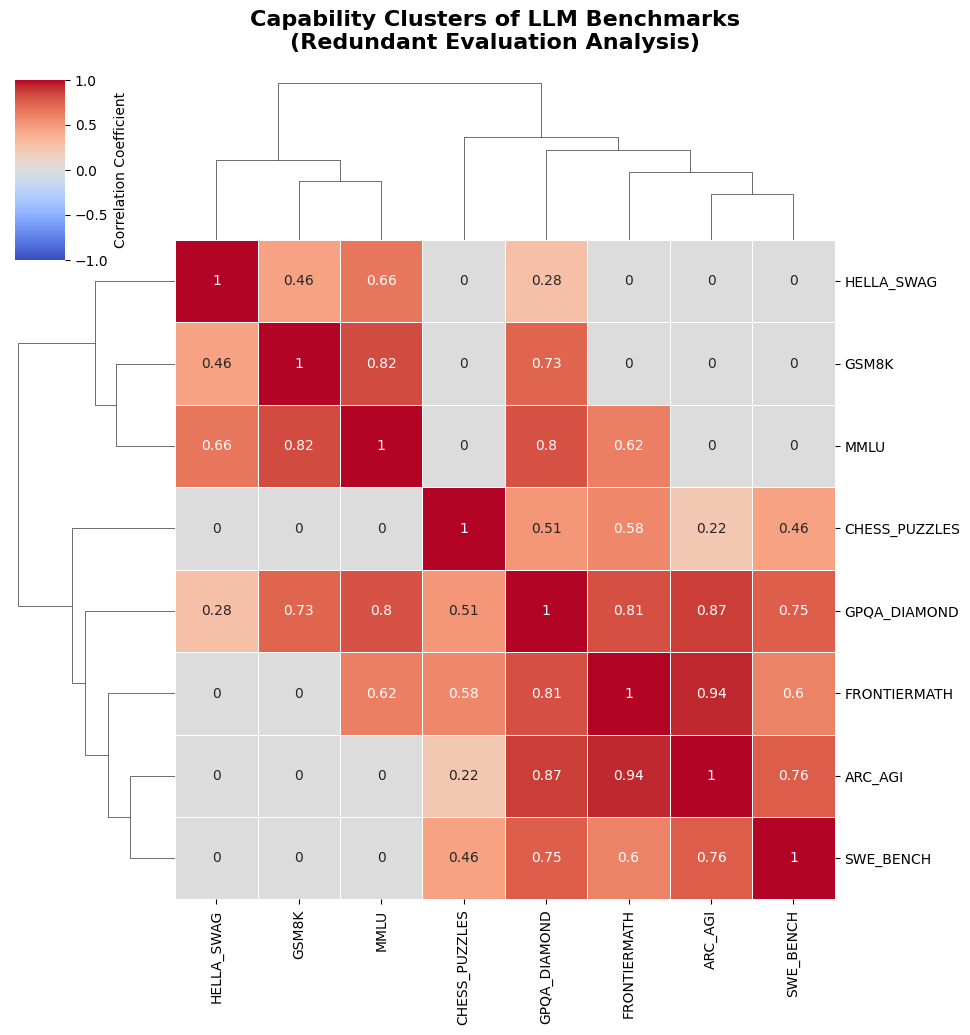

In [31]:

# ==========================================
# 1. Structural Analysis: Model-by-Benchmark Matrix
# ==========================================
# Create a pivot table: Rows = Models, Columns = Benchmarks
pivot_df = df.pivot_table(index='model_name', columns='benchmark_name', values='score')

# Calculate the Pearson correlation matrix between benchmarks
corr_matrix = pivot_df.corr().fillna(0)

# ==========================================
# 2. Plot the Clustered Heatmap
# ==========================================
# Use seaborn's clustermap to automatically perform hierarchical clustering
g = sns.clustermap(
    corr_matrix, 
    annot=True,              # Show correlation numbers in the boxes
    cmap='coolwarm',         # Blue for negative, Red for positive correlation
    vmin=-1, vmax=1,         # Correlation ranges from -1 to 1
    linewidths=0.5,
    figsize=(10, 10),        # Make the figure slightly larger for 8 benchmarks
    cbar_kws={'label': 'Correlation Coefficient'}
)

# Set the title
g.fig.suptitle('Capability Clusters of LLM Benchmarks\n(Redundant Evaluation Analysis)', y=1.05, fontsize=16, fontweight='bold')

# Remove the ugly default x and y axis labels
g.ax_heatmap.set_xlabel('')
g.ax_heatmap.set_ylabel('')

# Save and show the plot
plt.savefig('clustering_analysis.png', dpi=300, bbox_inches='tight')
plt.show()